
Loading Dataset...

Dataset Loaded Successfully!

Dataset Shape
-------------------------
Rows : 1000
Columns : 16

First 10 Records
-------------------------
   student_id  gender branch  year       GPA  skill_python  skill_ml  \
0           1    Male    CSE     2  7.559629             0         0   
1           2  Female     IT     2  9.234891             1         1   
2           3  Female    EEE     4  6.922240             1         1   
3           4  Female    ECE     2  6.217164             0         0   
4           5    Male    EEE     2  7.745770             0         1   
5           6    Male    ECE     3  8.668010             0         0   
6           7    Male    ECE     2  8.380338             0         0   
7           8  Female    EEE     3  7.635778             1         1   
8           9  Female    CSE     1  8.484690             1         0   
9          10  Female     IT     2  9.155923             1         1   

   skill_sql  skill_cloud  interest_ai  interes

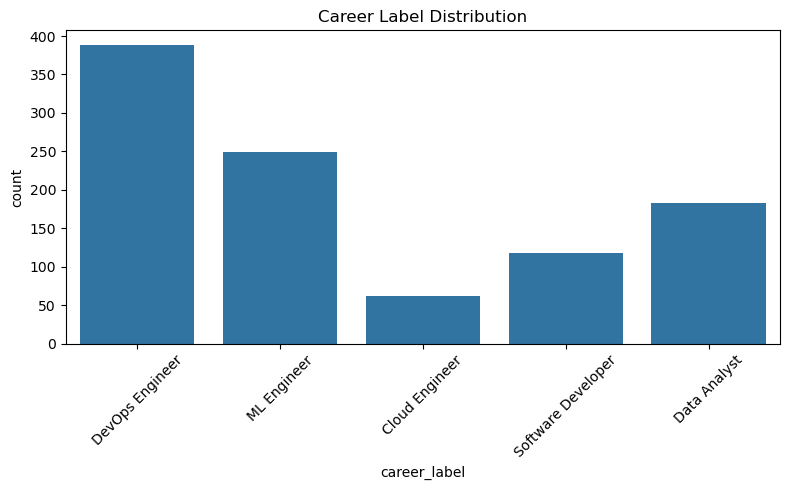

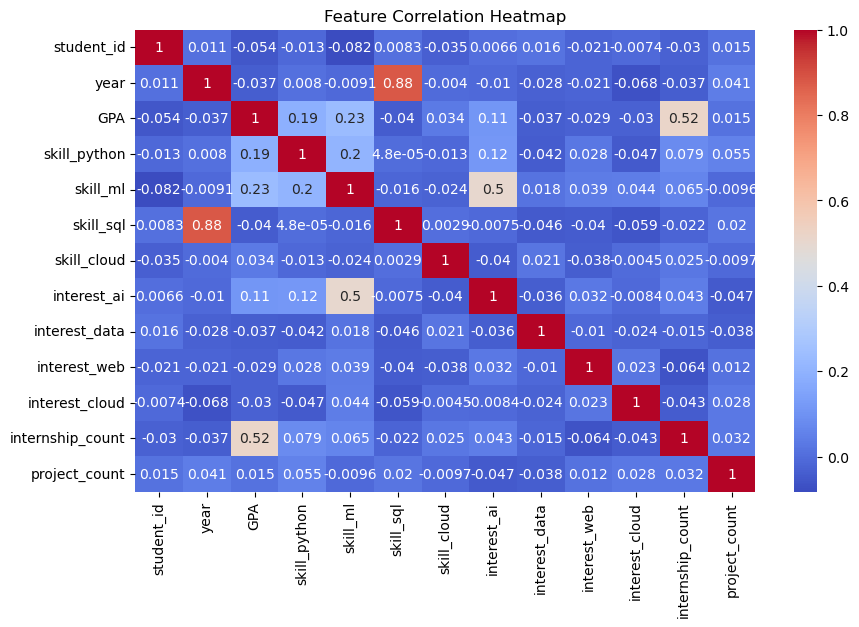


Clean dataset saved as 'dataset_checked.csv'

MODULE 1 COMPLETED SUCCESSFULLY


In [16]:
# ==============================================================
# MODULE 1
# DATA COLLECTION & DATA UNDERSTANDING
# Project: Learning Path Recommender for Students
# ==============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================
# 1. LOAD DATASET
# ==============================================================

print("\nLoading Dataset...\n")

df = pd.read_csv("D:\projects\ML\learning-path-recommender\data\Dataset/final_hybrid_learning_path_dataset_v2.csv")

print("Dataset Loaded Successfully!")

# ==============================================================
# 2. DATASET SHAPE
# ==============================================================

print("\nDataset Shape")
print("-------------------------")
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

# ==============================================================
# 3. DISPLAY SAMPLE RECORDS
# ==============================================================

print("\nFirst 10 Records")
print("-------------------------")
print(df.head(10))

# ==============================================================
# 4. DATASET INFORMATION
# ==============================================================

print("\nDataset Information")
print("-------------------------")
df.info()

# ==============================================================
# 5. CHECK MISSING VALUES
# ==============================================================

print("\nMissing Values")
print("-------------------------")
print(df.isnull().sum())

# ==============================================================
# 6. DESCRIPTIVE STATISTICS
# ==============================================================

print("\nDataset Statistics")
print("-------------------------")
print(df.describe())

# ==============================================================
# 7. UNIQUE VALUES IN CATEGORICAL FEATURES
# ==============================================================

print("\nUnique Values in Categorical Columns")
print("-------------------------")

categorical_columns = ["gender", "branch", "career_label"]

for col in categorical_columns:
    print(f"\n{col} unique values:")
    print(df[col].unique())

# ==============================================================
# 8. TARGET VARIABLE DISTRIBUTION
# ==============================================================

print("\nCareer Label Distribution")
print("-------------------------")
print(df["career_label"].value_counts())

# ==============================================================
# 9. CHECK DUPLICATE RECORDS
# ==============================================================

print("\nDuplicate Rows")
print("-------------------------")

duplicates = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicates)

# ==============================================================
# 10. VISUALIZATION - TARGET VARIABLE
# ==============================================================

plt.figure(figsize=(8,5))
sns.countplot(x="career_label", data=df)
plt.title("Career Label Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================================================
# 11. CORRELATION HEATMAP
# ==============================================================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ==============================================================
# 12. SAVE CHECKED DATASET
# ==============================================================

df.to_csv("D:\projects\ML\learning-path-recommender\data\Dataset\dataset_checked.csv", index=False)

print("\nClean dataset saved as 'dataset_checked.csv'")

print("\nMODULE 1 COMPLETED SUCCESSFULLY")

In [18]:
# ==============================================================
# MODULE 2
# DATA PREPROCESSING
# ==============================================================

import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("\nLoading Checked Dataset...\n")

df = pd.read_csv(r"D:/projects/ML/learning-path-recommender/data/Dataset/dataset_checked.csv")

print("Dataset Loaded Successfully!")

# ==============================================================
# HANDLE MISSING VALUES
# ==============================================================

df.fillna(method="ffill", inplace=True)

# ==============================================================
# ENCODE CATEGORICAL FEATURES
# ==============================================================

label_encoder = LabelEncoder()

categorical_cols = ["gender", "branch", "career_label"]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# ==============================================================
# FEATURE / TARGET SPLIT
# ==============================================================

X = df.drop("career_label", axis=1)
y = df["career_label"]

# ==============================================================
# FEATURE SCALING
# ==============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==============================================================
# TRAIN TEST SPLIT
# ==============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==============================================================
# SAVE PREPROCESSED DATA
# ==============================================================

os.makedirs("processed_data", exist_ok=True)

pd.DataFrame(X_train).to_csv("processed_data/X_train.csv", index=False)
pd.DataFrame(X_test).to_csv("processed_data/X_test.csv", index=False)

pd.DataFrame(y_train).to_csv("processed_data/y_train.csv", index=False)
pd.DataFrame(y_test).to_csv("processed_data/y_test.csv", index=False)

print("\nPreprocessed data saved successfully!")

print("\nMODULE 2 COMPLETED SUCCESSFULLY")


Loading Checked Dataset...

Dataset Loaded Successfully!

Preprocessed data saved successfully!

MODULE 2 COMPLETED SUCCESSFULLY


C:\Users\premk\AppData\Local\Temp\ipykernel_11804\1834224320.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [19]:
# ==============================================================
# MODULE 3
# MODEL TRAINING & EVALUATION
# Project: Learning Path Recommender for Students
# ==============================================================

import pandas as pd
import os
import joblib
!pip install xgboost


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier


# ==============================================================
# 1. LOAD PREPROCESSED DATA
# ==============================================================

print("\nLoading Preprocessed Data...\n")

X_train = pd.read_csv("processed_data/X_train.csv")
X_test = pd.read_csv("processed_data/X_test.csv")

y_train = pd.read_csv("processed_data/y_train.csv")
y_test = pd.read_csv("processed_data/y_test.csv")

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Data Loaded Successfully!")

# ==============================================================
# 2. INITIALIZE MODELS
# ==============================================================

print("\nInitializing Models...\n")

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Support Vector Machine": SVC(
        kernel="rbf"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss"
    )
}

# ==============================================================
# 3. TRAIN MODELS
# ==============================================================

results = {}

for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[model_name] = accuracy

    print(f"{model_name} Accuracy: {accuracy:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, predictions))


# ==============================================================
# 4. MODEL COMPARISON
# ==============================================================

print("\nModel Comparison")
print("----------------------------")

for model, score in results.items():
    print(f"{model} : {score:.4f}")

best_model_name = max(results, key=results.get)

print("\nBest Model:", best_model_name)


# ==============================================================
# 5. TRAIN BEST MODEL AGAIN
# ==============================================================

best_model = models[best_model_name]

best_model.fit(X_train, y_train)


# ==============================================================
# 6. SAVE BEST MODEL
# ==============================================================

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/best_model.pkl")

print("\nBest model saved as 'models/best_model.pkl'")

print("\nMODULE 3 COMPLETED SUCCESSFULLY")


Loading Preprocessed Data...

Data Loaded Successfully!

Initializing Models...


Training Random Forest...
Random Forest Accuracy: 0.9550

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.53      0.69        19
           1       1.00      1.00      1.00        35
           2       0.90      1.00      0.95        79
           3       1.00      1.00      1.00        43
           4       1.00      1.00      1.00        24

    accuracy                           0.95       200
   macro avg       0.98      0.91      0.93       200
weighted avg       0.96      0.95      0.95       200


Training Logistic Regression...
Logistic Regression Accuracy: 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        79
           3       1.00      1.00     


Loading Preprocessed Data...

Data Loaded Successfully!
Train Size: (800, 15)
Test Size : (200, 15)

Initializing Models...

--------------------------------
Training Random Forest
--------------------------------
Test Accuracy : 0.8000
CV Accuracy   : 0.8488

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       1.00      1.00      1.00        35
           2       0.69      0.97      0.81        79
           3       0.90      1.00      0.95        43
           4       1.00      0.21      0.34        24

    accuracy                           0.80       200
   macro avg       0.72      0.64      0.62       200
weighted avg       0.76      0.80      0.74       200

--------------------------------
Training Logistic Regression
--------------------------------
Test Accuracy : 0.9900
CV Accuracy   : 0.9775

Classification Report:

              precision    recall  f1-score   support

    

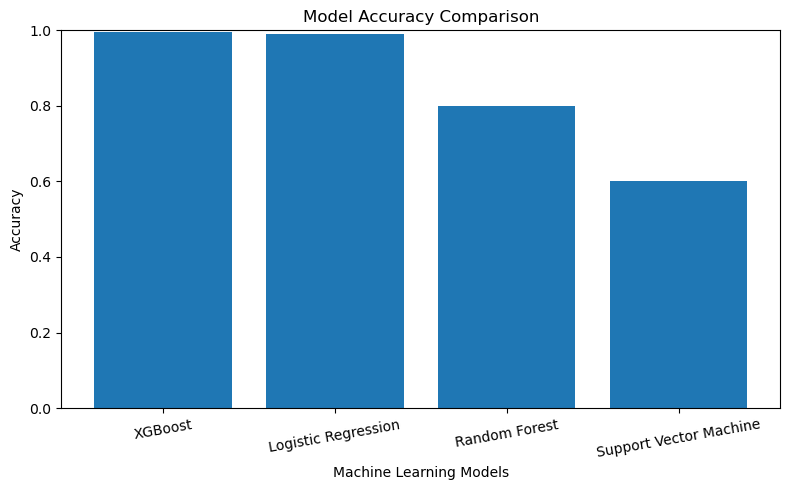

Chart saved -> models/model_accuracy_comparison.png

Best Model Selected: XGBoost
Best model saved -> models/best_model.pkl

MODULE 3 COMPLETED SUCCESSFULLY


In [29]:
# ==============================================================
# MODULE 3
# MODEL TRAINING & EVALUATION
# ==============================================================

import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier


# ==============================================================
# 1. LOAD PREPROCESSED DATA
# ==============================================================

print("\nLoading Preprocessed Data...\n")

X_train = pd.read_csv("processed_data/X_train.csv")
X_test  = pd.read_csv("processed_data/X_test.csv")

y_train = pd.read_csv("processed_data/y_train.csv").values.ravel()
y_test  = pd.read_csv("processed_data/y_test.csv").values.ravel()

print("Data Loaded Successfully!")
print(f"Train Size: {X_train.shape}")
print(f"Test Size : {X_test.shape}")


# ==============================================================
# 2. ADD SMALL NOISE TO TRAINING DATA
# ==============================================================

rng = np.random.default_rng(seed=42)

noise = rng.normal(
    loc=0.0,
    scale=0.15 * X_train.std(axis=0).values,
    size=X_train.shape
)

X_train_noisy = X_train + noise


# ==============================================================
# 3. INITIALIZE MODELS
# ==============================================================

print("\nInitializing Models...\n")

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=4,
        min_samples_split=15,
        min_samples_leaf=8,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=500,
        C=0.1
    ),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=0.1, gamma=0.01))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=60,
        learning_rate=0.08,
        max_depth=3,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_lambda=5,
        random_state=42,
        eval_metric="mlogloss"
    )
}


# ==============================================================
# 4. TRAIN MODELS
# ==============================================================

results = {}

for name, model in models.items():

    print("--------------------------------")
    print(f"Training {name}")
    print("--------------------------------")

    model.fit(X_train_noisy, y_train)

    predictions = model.predict(X_test)

    test_accuracy = accuracy_score(y_test, predictions)

    cv_scores = cross_val_score(model, X_train_noisy, y_train, cv=5)
    cv_accuracy = cv_scores.mean()

    results[name] = {
        "test": test_accuracy,
        "cv": cv_accuracy
    }

    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"CV Accuracy   : {cv_accuracy:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions, zero_division=0))


# ==============================================================
# 5. MODEL COMPARISON TABLE
# ==============================================================

print("\nMODEL COMPARISON")
print("=" * 40)

comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Test Accuracy": [v["test"] for v in results.values()],
    "CV Accuracy": [v["cv"] for v in results.values()]
})

comparison_df = comparison_df.sort_values(by="Test Accuracy", ascending=False)

print(comparison_df.to_string(index=False))


# ==============================================================
# 6. VISUALIZATION
# ==============================================================

plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")

plt.ylim(0,1)

plt.xticks(rotation=10)

plt.tight_layout()

os.makedirs("models", exist_ok=True)

plt.savefig("models/model_accuracy_comparison.png")

plt.show()

print("Chart saved -> models/model_accuracy_comparison.png")


# ==============================================================
# 7. SELECT BEST MODEL
# ==============================================================

best_model_name = comparison_df.iloc[0]["Model"]

print("\nBest Model Selected:", best_model_name)

best_model = models[best_model_name]

best_model.fit(X_train_noisy, y_train)


# ==============================================================
# 8. SAVE MODEL
# ==============================================================

joblib.dump(best_model, "models/best_model.pkl")

print("Best model saved -> models/best_model.pkl")

print("\nMODULE 3 COMPLETED SUCCESSFULLY")

In [33]:
# ==============================================================
# MODULE 4
# LEARNING PATH RECOMMENDATION ENGINE
# ==============================================================

import numpy as np
import joblib


# ==============================================================
# 1. LOAD TRAINED MODEL
# ==============================================================

print("\nLoading trained model...\n")

model = joblib.load("models/best_model.pkl")

print("Model Loaded Successfully!")


# ==============================================================
# 2. CAREER LABEL MAPPING
# ==============================================================

career_labels = {
    0: "Web Developer",
    1: "Data Scientist",
    2: "Machine Learning Engineer",
    3: "Software Developer",
    4: "Cyber Security Specialist"
}


# ==============================================================
# 3. LEARNING PATH DATABASE
# ==============================================================

learning_paths = {

    "Web Developer": {
        "skills": ["HTML", "CSS", "JavaScript", "React", "Node.js"],
        "tools": ["VS Code", "Git", "GitHub", "Chrome DevTools"],
        "courses": ["Frontend Web Development", "JavaScript Programming", "React Development"]
    },

    "Data Scientist": {
        "skills": ["Python", "Statistics", "Data Analysis", "Machine Learning", "Data Visualization"],
        "tools": ["Python", "Pandas", "NumPy", "Jupyter Notebook", "Tableau"],
        "courses": ["Data Science Fundamentals", "Python for Data Science", "Machine Learning Basics"]
    },

    "Machine Learning Engineer": {
        "skills": ["Python", "Machine Learning", "Deep Learning", "Model Deployment"],
        "tools": ["TensorFlow", "PyTorch", "Scikit-learn", "Docker"],
        "courses": ["Machine Learning Specialization", "Deep Learning Fundamentals"]
    },

    "Software Developer": {
        "skills": ["Programming", "Data Structures", "Algorithms", "OOP"],
        "tools": ["C++", "Java", "Git", "VS Code"],
        "courses": ["Data Structures & Algorithms", "Software Engineering"]
    },

    "Cyber Security Specialist": {
        "skills": ["Network Security", "Ethical Hacking", "Cryptography"],
        "tools": ["Kali Linux", "Metasploit", "Wireshark"],
        "courses": ["Cyber Security Fundamentals", "Ethical Hacking"]
    }
}


# ==============================================================
# 4. GET USER INPUT (UNSEEN DATA)
# ==============================================================

print("\nEnter Student Details\n")

GPA = float(input("Enter GPA: "))
skill_python = int(input("Python Skill (1=yes, 0=no): "))
skill_ml = int(input("Machine Learning Skill (1=yes, 0=no): "))
skill_web = int(input("Web Development Skill (1=yes, 0=no): "))

interest_ai = int(input("Interest in AI (1=yes, 0=no): "))
interest_web = int(input("Interest in Web Development (1=yes, 0=no): "))
interest_data = int(input("Interest in Data Science (1=yes, 0=no): "))

branch_CSE = int(input("Branch CSE (1=yes, 0=no): "))
branch_ECE = int(input("Branch ECE (1=yes, 0=no): "))
branch_EEE = int(input("Branch EEE (1=yes, 0=no): "))
branch_Mechanical = int(input("Branch Mechanical (1=yes, 0=no): "))

internship_done = int(input("Internship Completed (1=yes, 0=no): "))
project_done = int(input("Project Completed (1=yes, 0=no): "))
certification = int(input("Certification (1=yes, 0=no): "))
hackathon = int(input("Hackathon Participation (1=yes, 0=no): "))


# ==============================================================
# 5. CREATE INPUT ARRAY
# ==============================================================

student_data = np.array([[

    GPA,
    skill_python,
    skill_ml,
    skill_web,
    interest_ai,
    interest_web,
    interest_data,
    branch_CSE,
    branch_ECE,
    branch_EEE,
    branch_Mechanical,
    internship_done,
    project_done,
    certification,
    hackathon

]])


# ==============================================================
# 6. PREDICT CAREER
# ==============================================================

prediction = model.predict(student_data)

career_index = prediction[0]

predicted_career = career_labels.get(career_index, "Unknown")

print("\nPredicted Career Path:", predicted_career)


# ==============================================================
# 7. GENERATE LEARNING PATH
# ==============================================================

path = learning_paths[predicted_career]

print("\nRecommended Skills:")
for skill in path["skills"]:
    print("-", skill)

print("\nRecommended Tools:")
for tool in path["tools"]:
    print("-", tool)

print("\nRecommended Courses:")
for course in path["courses"]:
    print("-", course)

print("\nLearning Path Recommendation Completed.")


Loading trained model...

Model Loaded Successfully!

Enter Student Details


Predicted Career Path: Data Scientist

Recommended Skills:
- Python
- Statistics
- Data Analysis
- Machine Learning
- Data Visualization

Recommended Tools:
- Python
- Pandas
- NumPy
- Jupyter Notebook
- Tableau

Recommended Courses:
- Data Science Fundamentals
- Python for Data Science
- Machine Learning Basics

Learning Path Recommendation Completed.
